In [1]:
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
import seaborn as sn

In [2]:
dataset=pd.read_csv('customer_churn.csv')
dataset[:5]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
dataset = dataset.replace(' ', np.nan)
dataset = dataset.ffill()

In [4]:
inputs=dataset.drop(['customerID','Churn'], axis='columns')
inputs[:2]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5


In [5]:
lb=LabelEncoder()
dataset.Churn=lb.fit_transform(dataset.Churn)
dataset[:1]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0


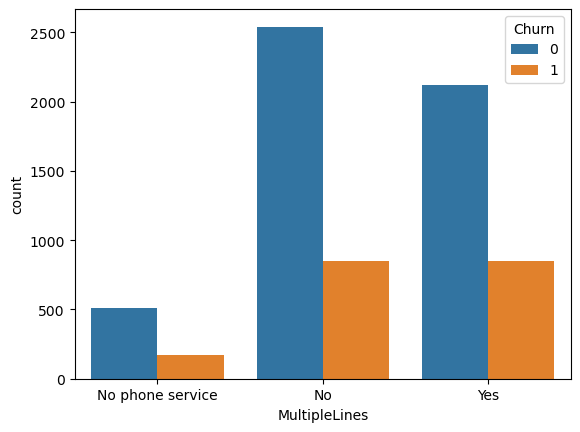

In [6]:
sn.countplot(data=dataset,
             x=dataset.MultipleLines,
            hue=dataset.Churn)
plt.show()

In [7]:
dataset.groupby('MultipleLines').size()

MultipleLines
No                  3390
No phone service     682
Yes                 2971
dtype: int64

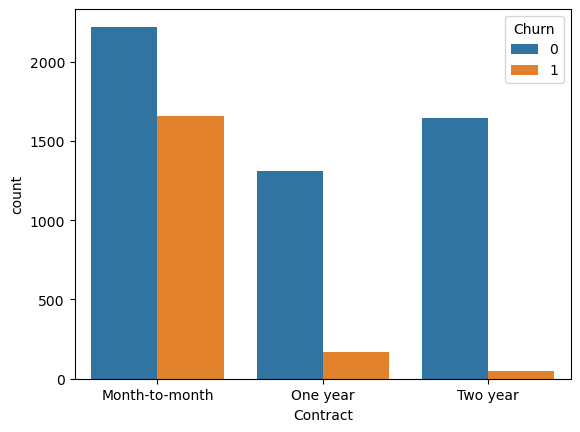

In [8]:
sn.countplot(data=dataset,
             x=dataset.Contract,
            hue=dataset.Churn)
plt.show()

<Axes: xlabel='PaymentMethod', ylabel='count'>

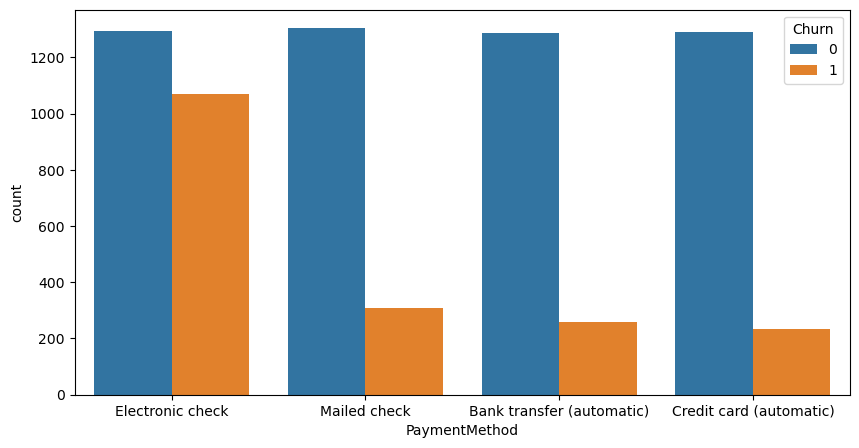

In [9]:
plt.figure(figsize=(10,5))
sn.countplot(data=dataset,
             x=dataset.PaymentMethod,
            hue=dataset.Churn,
            )

In [10]:
dataset.groupby('PaymentMethod').size()

PaymentMethod
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Electronic check             2365
Mailed check                 1612
dtype: int64

In [11]:
column_list = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
    'PaymentMethod'
]

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first'), column_list)
    ],
    remainder='passthrough'
)

inputs = ct.fit_transform(inputs)
inputs= inputs[:, 1:]
inputs = inputs.astype('float32')
inputs[:2]

array([[0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 1.0000e+00, 2.9850e+01, 2.9850e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 3.4000e+01, 5.6950e+01, 1.8895e+03]], dtype=float32)

In [12]:
target=dataset.Churn
target[:10]

0    0
1    0
2    1
3    0
4    1
5    1
6    0
7    0
8    1
9    0
Name: Churn, dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test= train_test_split(inputs, target, test_size= 0.2)

In [15]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [16]:
X_train[:2]

array([[-0.43602073,  1.0335772 , -0.6534919 ,  0.32758406, -0.32758406,
        -0.860211  ,  1.1277297 , -0.5260062 , -0.5260062 , -0.6281357 ,
        -0.5260062 , -0.7238358 , -0.5260062 , -0.72469026, -0.5260062 ,
        -0.639691  , -0.5260062 , -0.7902958 , -0.5260062 , -0.80100465,
        -0.5141621 , -0.5616343 , -1.2075244 , -0.52903   ,  1.4080236 ,
        -0.5443937 , -1.1126602 ,  0.17021425, -0.86116076],
       [ 2.293469  , -0.96751356, -0.6534919 ,  0.32758406, -0.32758406,
        -0.860211  ,  1.1277297 , -0.5260062 , -0.5260062 , -0.6281357 ,
        -0.5260062 , -0.7238358 , -0.5260062 , -0.72469026, -0.5260062 ,
        -0.639691  , -0.5260062 , -0.7902958 , -0.5260062 , -0.80100465,
        -0.5141621 , -0.5616343 ,  0.8281406 , -0.52903   ,  1.4080236 ,
        -0.5443937 , -1.153291  ,  0.1934188 , -0.87712246]],
      dtype=float32)

In [17]:
len(X_train)

5634

In [18]:
ANN_model = keras.Sequential([
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
ANN_model.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])
ANN_model.fit(X_train, y_train, epochs=30,
              batch_size=32,
              class_weight={0:1, 1:2})

Epoch 1/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7474 - loss: 0.6875
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7648 - loss: 0.6379
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7648 - loss: 0.6230
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7689 - loss: 0.6228
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7741 - loss: 0.6109
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7767 - loss: 0.6092
Epoch 7/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7838 - loss: 0.6003
Epoch 8/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7849 - loss: 0.6017
Epoch 9/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7824 - loss: 0.6006
Epoch 10/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7783 - loss: 0.6028
Epoch 11/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7819 - loss: 0.5981
Epoch 12/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [19]:
ANN_model.evaluate(X_test, y_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7757 - loss: 0.4708


[0.4708205461502075, 0.7757274508476257]

In [20]:
ANN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           3,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,629 (166.52 KB)

 Trainable params: 14,209 (55.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 28,420 (111.02 KB)